In [1]:
import pandas as pd
pd.set_option('display.max_rows', 150)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import seaborn as sns
from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova
from matplotlib_venn import venn2

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mutcat_path = "data/positions_mutcat.tsv"
gsva_path = "data/GSVA_pathway_scores_newLGGUCEC.tsv"
nomut_path = "data/tcga_WT-ongs-tsgs_no-somatic-germline_ascat_gene-level-zygosity_hg19.tsv"
roles_path = 'data/generoles.tsv'

In [3]:
mutcat = pd.read_csv(mutcat_path, sep='\t')
gsva = pd.read_csv(gsva_path, sep='\t')
nomut = pd.read_csv(nomut_path, sep='\t')
roles = pd.read_csv(roles_path, sep = '\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (14) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 2H

In [5]:
# preparing dataset

mutcat['tissue'] = mutcat['gene_patient'].apply(lambda x:x.split('_')[1])

gsva_mod = gsva.reset_index()
gsva_mod['index'] = gsva_mod['index'].apply(lambda x:x.replace('.','-'))
gsva_mod = gsva_mod.set_index('index')

wtsamples = nomut[(nomut['gene']=='TP53')&(nomut['zygosity']=='0-hit')&(nomut['cancer_type']=='LGG')].tissue.unique()
wtdelsamples = nomut[(nomut['gene']=='TP53')&(nomut['zygosity']=='1-hit')&(nomut['cancer_type']=='LGG')].tissue.unique()

mut = mutcat[(mutcat['Hugo_Symbol']=='TP53')&(mutcat['Protein_position']==273)&(mutcat['Mutation_Category_genepatient']=='mis')&(mutcat['CODE']=='LGG')].copy()
mut1samples = mut[mut.zygosity_genepatient=='1-hit'].tissue.unique()
mut2samples = mut[mut.zygosity_genepatient=='2-hit'].tissue.unique()

sample_groups = pd.Series("Other", index=gsva_mod.index)

sample_groups.loc[gsva_mod.index.isin(mut1samples)] = "Mutation1"
sample_groups.loc[gsva_mod.index.isin(mut2samples)] = "Mutation2"
sample_groups.loc[gsva_mod.index.isin(wtsamples)] = "WT"
sample_groups.loc[gsva_mod.index.isin(wtdelsamples)] = "WTdel"

keep_samples = (
    gsva_mod.index.isin(mut1samples) |
    gsva_mod.index.isin(mut2samples) |
    gsva_mod.index.isin(wtsamples) |
    gsva_mod.index.isin(wtdelsamples)
)

gsva_sub = gsva_mod.loc[keep_samples]

In [6]:
# WT vs Mutant 

results = []

for pathway in gsva_mod.columns:
    wt = gsva_mod[gsva_mod.index.isin(wtsamples)][pathway] 
    mut = gsva_mod[gsva_mod.index.isin(list(mut1samples)+list(mut2samples))][pathway]

    stat, p = mannwhitneyu(wt, mut, alternative="two-sided")

    results.append({
        "pathway": pathway,
        "pval": p,
        "wt_median": wt.median(),
        "mut_median": mut.median()
    })

res_df = pd.DataFrame(results)

# FDR correction
res_df["fdr"] = multipletests(res_df["pval"], method="fdr_bh")[1]

print(len(res_df[res_df['fdr']<0.05]))

20


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


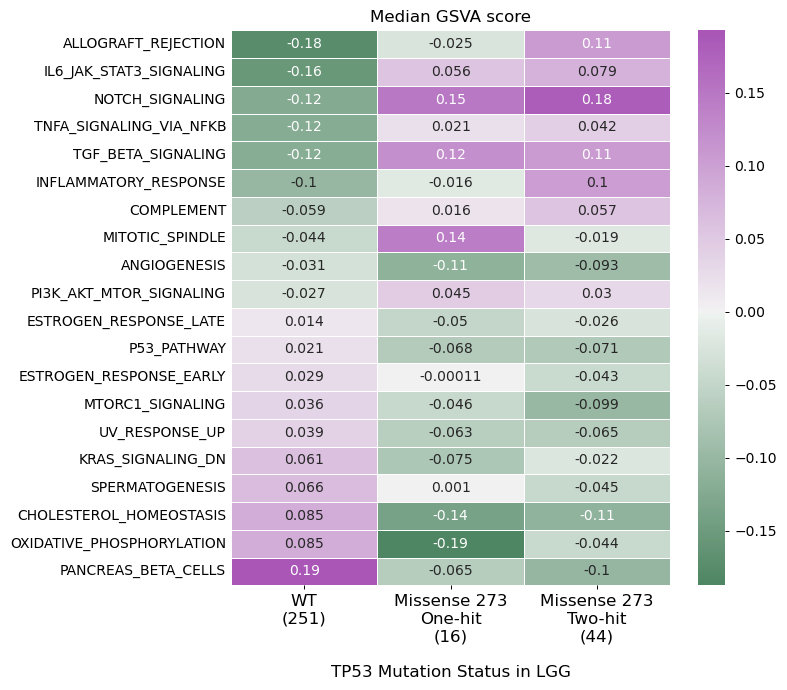

In [7]:
# Heatmap: TP53

config_rcparams()

gsva_subsub = gsva_sub[list(res_df[res_df['fdr']<0.05]['pathway'].values)]

# Remove 'HALLMARK_' prefix and format column names
gsva_subsub.columns = (
    gsva_subsub.columns
    .str.replace(r"^HALLMARK_", "", regex=True)  # remove prefix
)

wt = gsva_subsub.loc[gsva_subsub.index.intersection(wtsamples)]
mut1 = gsva_subsub.loc[gsva_subsub.index.intersection(mut1samples)]
mut2 = gsva_subsub.loc[gsva_subsub.index.intersection(mut2samples)]

# median per pathway
median_df = pd.DataFrame({
    "WT\n(251)": wt.median(axis=0),
    "Missense 273\nOne-hit\n(16)": mut1.median(axis=0),
    "Missense 273\nTwo-hit\n(44)": mut2.median(axis=0)
})

median_df = median_df.sort_values(by='WT\n(251)')

plt.figure(figsize=(8,0.35 * median_df.shape[0]))

palette = sns.diverging_palette(500, 300, s=60, as_cmap=True)

ax = sns.heatmap(
    median_df,
    cmap=palette, #"vlag",
    center=0,
    linewidths=0.5, annot=True
)

plt.title("Median GSVA score")
ax.tick_params(axis="x", labelsize=12)
ax.set_xlabel("TP53 Mutation Status in LGG", fontsize=12, labelpad=15)

ax.tick_params(axis="y", length=0)
plt.tight_layout()

plt.show()

---

# Fig 2I

In [8]:
# preparing dataset

wtsamples = nomut[(nomut['gene']=='PTEN')&(nomut['zygosity']=='0-hit')&(nomut['cancer_type']=='UCEC')].tissue.unique()
wtdelsamples = nomut[(nomut['gene']=='PTEN')&(nomut['zygosity']=='1-hit')&(nomut['cancer_type']=='UCEC')].tissue.unique()

mut = mutcat[(mutcat['Hugo_Symbol']=='PTEN')&(mutcat['Protein_position']==130)&(mutcat['Mutation_Category_genepatient']=='mis')&(mutcat['CODE']=='UCEC')].copy()
mut1samples = mut[mut.zygosity_genepatient=='1-hit'].tissue.unique()
mut2samples = mut[mut.zygosity_genepatient=='2-hit'].tissue.unique()

sample_groups = pd.Series("Other", index=gsva_mod.index)

sample_groups.loc[gsva_mod.index.isin(mut1samples)] = "Mutation1"
sample_groups.loc[gsva_mod.index.isin(mut2samples)] = "Mutation2"
sample_groups.loc[gsva_mod.index.isin(wtsamples)] = "WT"
sample_groups.loc[gsva_mod.index.isin(wtdelsamples)] = "WTdel"

sample_groups.value_counts()

keep_samples = (
    gsva_mod.index.isin(mut1samples) |
    gsva_mod.index.isin(mut2samples) |
    gsva_mod.index.isin(wtsamples) |
    gsva_mod.index.isin(wtdelsamples)
)

gsva_sub = gsva_mod.loc[keep_samples]

In [9]:
# WT vs Mutant 

results = []

for pathway in gsva_mod.columns:
    wt = gsva_mod[gsva_mod.index.isin(wtsamples)][pathway] 
    mut = gsva_mod[gsva_mod.index.isin(list(mut1samples)+list(mut2samples))][pathway]

    stat, p = mannwhitneyu(wt, mut, alternative="two-sided")

    results.append({
        "pathway": pathway,
        "pval": p,
        "wt_median": wt.median(),
        "mut_median": mut.median()
    })

res_df = pd.DataFrame(results)

# FDR correction
res_df["fdr"] = multipletests(res_df["pval"], method="fdr_bh")[1]

print(len(res_df[res_df['fdr']<0.05]))

14


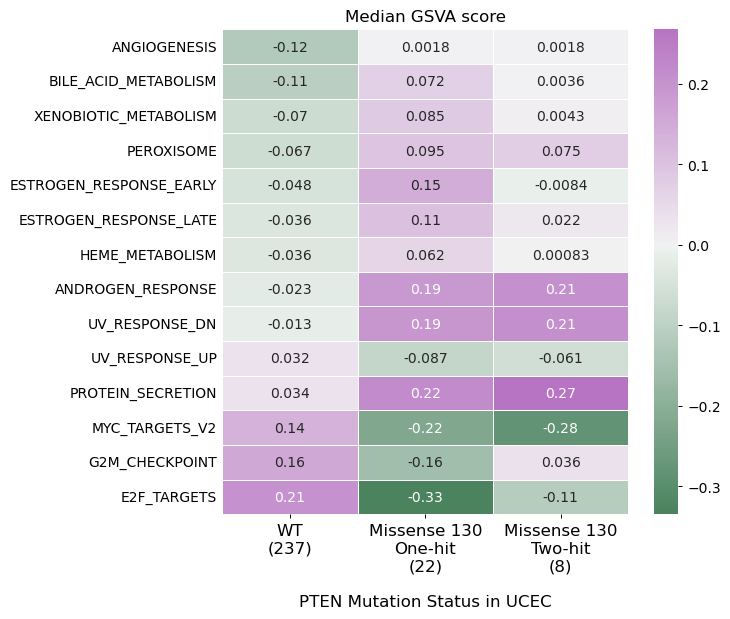

In [10]:
# Heatmap: PTEN

config_rcparams()

gsva_subsub = gsva_sub[list(res_df[res_df['fdr']<0.05]['pathway'].values)]

# Remove 'HALLMARK_' prefix and format column names
gsva_subsub.columns = (
    gsva_subsub.columns
    .str.replace(r"^HALLMARK_", "", regex=True)  # remove prefix
)

wt = gsva_subsub.loc[gsva_subsub.index.intersection(wtsamples)]
#wtdel = gsva_subsub.loc[gsva_subsub.index.intersection(wtdelsamples)]
mut1 = gsva_subsub.loc[gsva_subsub.index.intersection(mut1samples)]
mut2 = gsva_subsub.loc[gsva_subsub.index.intersection(mut2samples)]

# median per pathway
median_df = pd.DataFrame({
    "WT\n(237)": wt.median(axis=0),
    #"Single\ndeletion": wtdel.median(axis=0),
    "Missense 130\nOne-hit\n(22)": mut1.median(axis=0),
    "Missense 130\nTwo-hit\n(8)": mut2.median(axis=0)
})

median_df = median_df.sort_values(by='WT\n(237)')

plt.figure(figsize=(7.5,0.45 * median_df.shape[0]))

palette = sns.diverging_palette(500, 300, s=60, as_cmap=True)


ax = sns.heatmap(
    median_df,
    cmap=palette, #"vlag",
    center=0,
    linewidths=0.5, annot=True
)

plt.title("Median GSVA score")
ax.tick_params(axis="x", labelsize=12)
ax.set_xlabel("PTEN Mutation Status in UCEC", fontsize=12, labelpad=15)
ax.tick_params(axis="y", length=0)
plt.tight_layout()

plt.show()

---

# Fig 2J

In [11]:
# preparing dataset

wtsamples = nomut[(nomut['gene']=='CIC')&(nomut['zygosity']=='0-hit')&(nomut['cancer_type']=='LGG')].tissue.unique()
wtdelsamples = nomut[(nomut['gene']=='CIC')&(nomut['zygosity']=='1-hit')&(nomut['cancer_type']=='LGG')].tissue.unique()

mut = mutcat[(mutcat['Hugo_Symbol']=='CIC')&(mutcat['zygosity_genepatient']=='2-hit')&(mutcat['CODE']=='LGG')].copy()
mut1samples = mut[(mut.Mutation_Category_genepatient=='mis')&(((mut.Protein_position>200)&(mut.Protein_position<230))|((mut.Protein_position>1500)))].tissue.unique()
mut2samples = mut[mut.Mutation_Category_genepatient=='lof'].tissue.unique()

sample_groups = pd.Series("Other", index=gsva_mod.index)

sample_groups.loc[gsva_mod.index.isin(mut1samples)] = "Mutation1"
sample_groups.loc[gsva_mod.index.isin(mut2samples)] = "Mutation2"
sample_groups.loc[gsva_mod.index.isin(wtsamples)] = "WT"
sample_groups.loc[gsva_mod.index.isin(wtdelsamples)] = "WTdel"

keep_samples = (
    gsva_mod.index.isin(mut1samples) |
    gsva_mod.index.isin(mut2samples) |
    gsva_mod.index.isin(wtsamples) |
    gsva_mod.index.isin(wtdelsamples)
)

gsva_sub = gsva_mod.loc[keep_samples]

In [12]:
# WT vs Mutant 

results = []

for pathway in gsva_mod.columns:
    wt = gsva_mod[gsva_mod.index.isin(wtdelsamples)][pathway] 
    mut = gsva_mod[gsva_mod.index.isin(list(mut1samples)+list(mut2samples))][pathway]

    stat, p = mannwhitneyu(wt, mut, alternative="two-sided")

    results.append({
        "pathway": pathway,
        "pval": p,
        "wt_median": wt.median(),
        "mut_median": mut.median()
    })

res_df = pd.DataFrame(results)

# FDR correction
res_df["fdr"] = multipletests(res_df["pval"], method="fdr_bh")[1]

print(len(res_df[res_df['fdr']<0.05]))

12


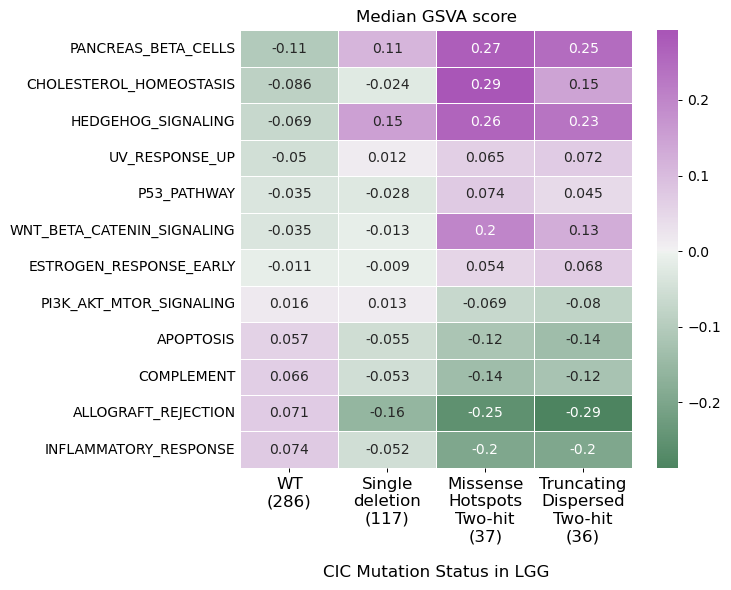

In [13]:
# Heatmap: CIC

config_rcparams()

gsva_subsub = gsva_sub[list(res_df[res_df['fdr']<0.05]['pathway'].values)]

# Remove 'HALLMARK_' prefix and format column names
gsva_subsub.columns = (
    gsva_subsub.columns
    .str.replace(r"^HALLMARK_", "", regex=True)  # remove prefix
)

wt = gsva_subsub.loc[gsva_subsub.index.intersection(wtsamples)]
wtdel = gsva_subsub.loc[gsva_subsub.index.intersection(wtdelsamples)]
mut1 = gsva_subsub.loc[gsva_subsub.index.intersection(mut1samples)]
mut2 = gsva_subsub.loc[gsva_subsub.index.intersection(mut2samples)]

# median per pathway
median_df = pd.DataFrame({
    "WT\n(286)": wt.median(axis=0),
    "Single\ndeletion\n(117)": wtdel.median(axis=0),
    "Missense\nHotspots\nTwo-hit\n(37)": mut1.median(axis=0),
    "Truncating\nDispersed\nTwo-hit\n(36)": mut2.median(axis=0)
})

median_df = median_df.sort_values(by='WT\n(286)')

plt.figure(figsize=(7.5,0.5 * median_df.shape[0]))

palette = sns.diverging_palette(500, 300, s=60, as_cmap=True)

ax = sns.heatmap(
    median_df,
    cmap=palette, #"vlag",
    center=0,
    linewidths=0.5, annot=True
)

plt.title("Median GSVA score")
ax.tick_params(axis="x", labelsize=12)
ax.set_xlabel("CIC Mutation Status in LGG", fontsize=12, labelpad=15)
ax.tick_params(axis="y", length=0)
plt.tight_layout()

plt.show()

---